In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import geopandas as gpd

In [2]:
file_path="Dataset/International_Education_Costs.csv"
df=pd.read_csv(file_path)
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


In [3]:
df.describe()

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [4]:
df.shape

(907, 12)

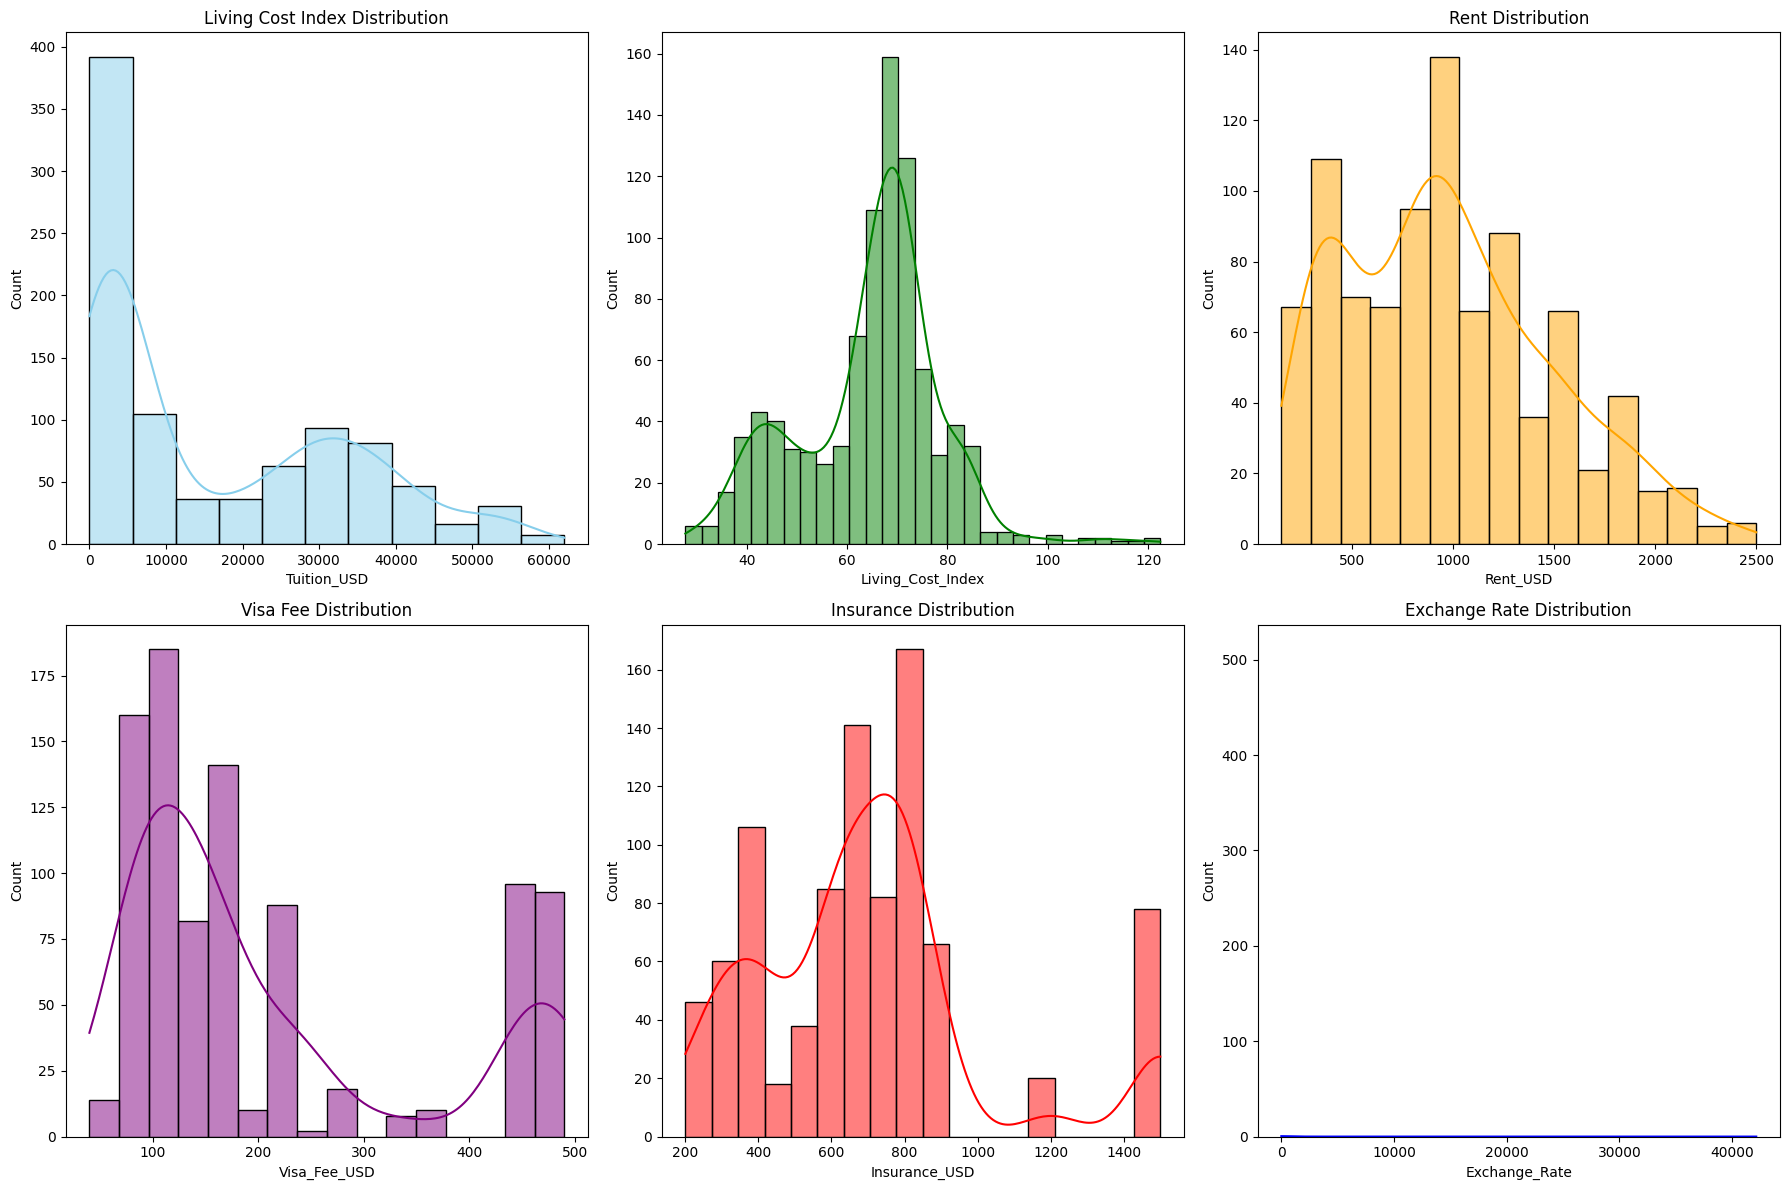

In [5]:
fig,axes=plt.subplots(2,3,figsize=(18,12))
sns.histplot(df['Tuition_USD'],kde=True,ax=axes[0,0],color='skyblue')
axes[0,0].set_title("Tution Distribution")

sns.histplot(df["Living_Cost_Index"],kde=True,ax=axes[0,1],color="green")
axes[0,0].set_title("Living Cost Index Distribution")

sns.histplot(df['Rent_USD'], kde=True, ax=axes[0, 2], color='orange')
axes[0, 2].set_title('Rent Distribution')

sns.histplot(df['Visa_Fee_USD'], kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Visa Fee Distribution')

sns.histplot(df['Insurance_USD'], kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Insurance Distribution')

sns.histplot(df['Exchange_Rate'], kde=True, ax=axes[1, 2], color='blue')
axes[1, 2].set_title('Exchange Rate Distribution')

plt.tight_layout()
plt.show()


In [8]:
correlation_matrix=df[['Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD', 'Insurance_USD', 'Exchange_Rate']].corr()
correlation_matrix

,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
Tuition_USD,1.000000,0.396830,0.724445,0.522490,0.582407,-0.116710
Living_Cost_Index,0.396830,1.000000,0.811128,0.256820,0.754393,-0.198685
Rent_USD,0.724445,0.811128,1.000000,0.374079,0.776770,-0.193944
Visa_Fee_USD,0.522490,0.256820,0.374079,1.000000,0.129655,-0.077886
Insurance_USD,0.582407,0.754393,0.776770,0.129655,1.000000,-0.189426
Exchange_Rate,-0.116710,-0.198685,-0.193944,-0.077886,-0.189426,1.000000


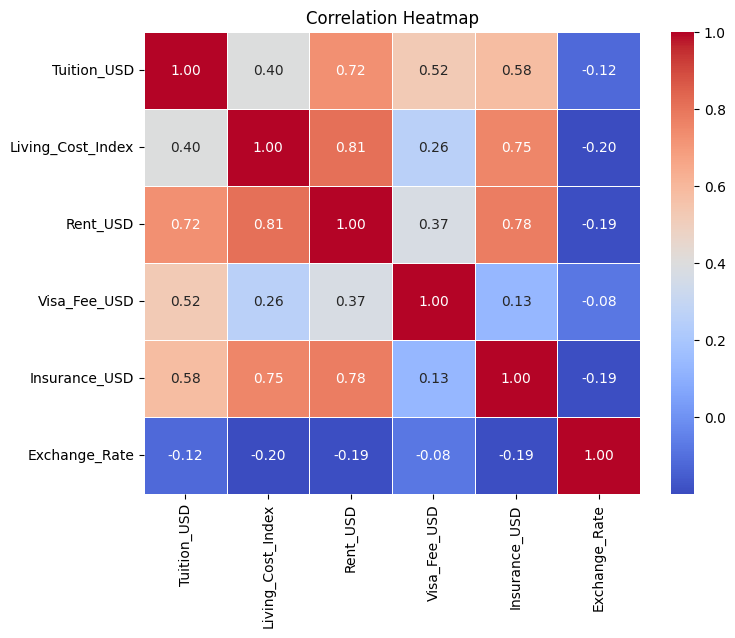

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

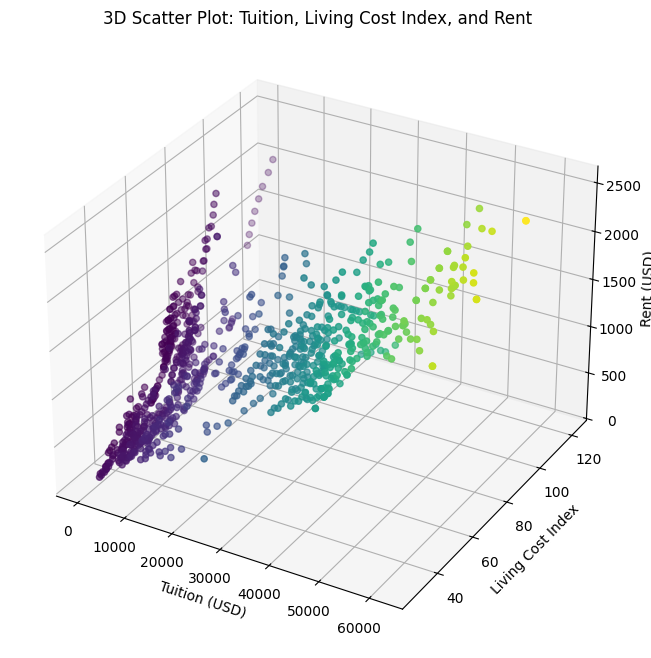

In [13]:
fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(df['Tuition_USD'], df['Living_Cost_Index'], df['Rent_USD'], c=df['Tuition_USD'], cmap='viridis')

ax.set_xlabel('Tuition (USD)')
ax.set_ylabel('Living Cost Index')
ax.set_zlabel('Rent (USD)')

ax.set_title('3D Scatter Plot: Tuition, Living Cost Index, and Rent')

plt.show()

In [21]:
country_avg=df.groupby('Country')["Tuition_USD"].mean().reset_index()
country_avg


,Country,Tuition_USD
0,Algeria,1100.000000
1,Argentina,0.000000
2,Australia,34610.465116
3,Austria,1500.000000
4,Bahrain,7600.000000
...,...,...
66,USA,47742.307692
67,Ukraine,3520.000000
68,Uruguay,2700.000000
69,Uzbekistan,3620.000000


C:\Users\DC\AppData\Local\Temp\ipykernel_17488\3446473401.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tuition_USD', y='Country', data=top_20_countries, palette='viridis')


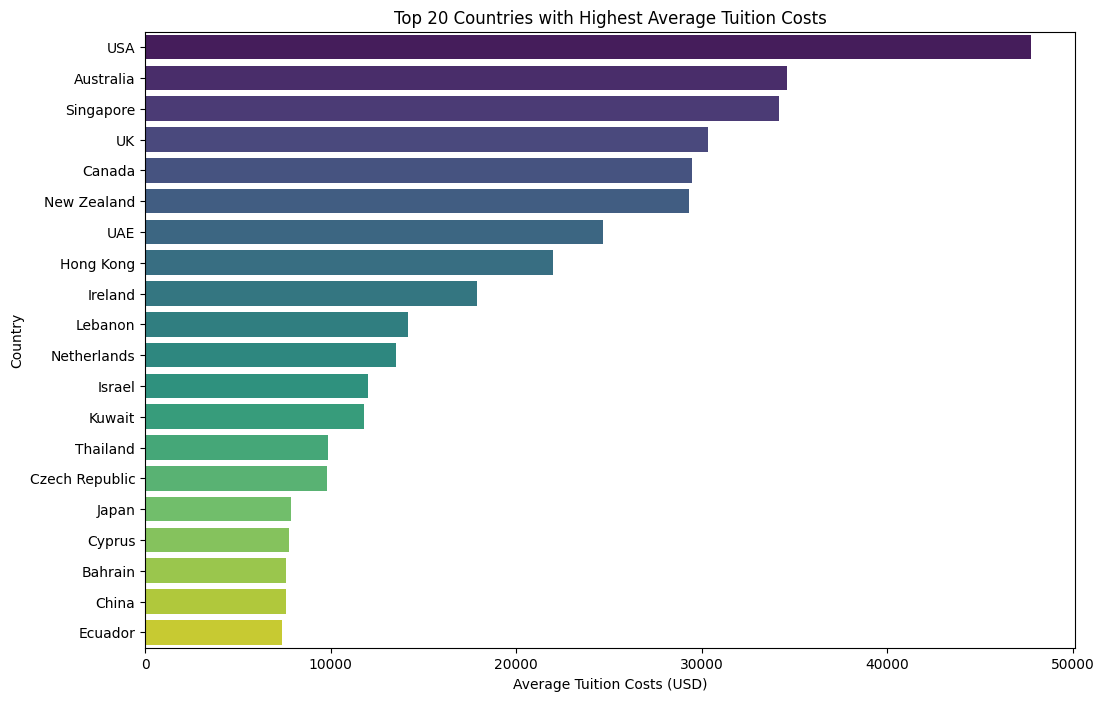

In [27]:
country_avg_tuition = df.groupby('Country')['Tuition_USD'].mean().reset_index()
top_20_countries=country_avg_tuition.sort_values(by="Tuition_USD",ascending=False).head(20)


plt.figure(figsize=(12, 8))
sns.barplot(x='Tuition_USD', y='Country', data=top_20_countries, palette='viridis')
plt.title('Top 20 Countries with Highest Average Tuition Costs')
plt.xlabel('Average Tuition Costs (USD)')
plt.ylabel('Country')
plt.show()

In [32]:
df_cleaned=df.dropna(subset=['Tuition_USD'])
X=df_cleaned[['Duration_Years', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD', 'Insurance_USD', 'Exchange_Rate']]
Y=df_cleaned["Tuition_USD"]

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)

In [34]:
lr_model=LinearRegression()
lr_model.fit(x_train_scaled,Y_train)

lr_pred=lr_model.predict(x_test_scaled)
lr_r2=r2_score(Y_test,lr_pred)
lr_mae=mean_absolute_error(Y_test,lr_pred)


print("Linear Regression Results:\nR-squared:", lr_r2, "\nMAE:", lr_mae)

Linear Regression Results:
R-squared: 0.6556641672835835 
MAE: 6704.7421217492965


In [37]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)
rf_pred=rf_model.predict(X_test)

rf_r2 = r2_score(Y_test, rf_pred)
rf_mae = mean_absolute_error(Y_test, rf_pred)

print("Random Forest Regressor Results:\nR-squared:", rf_r2, "\nMAE:", rf_mae)

Random Forest Regressor Results:
R-squared: 0.9410052356991739 
MAE: 2176.658673469388


In [39]:
svr_model=SVR(kernel='rbf')
svr_model.fit(x_train_scaled, Y_train)
svr_pred = svr_model.predict(x_test_scaled)

svr_r2 = r2_score(Y_test, svr_pred)
svr_mae = mean_absolute_error(Y_test, svr_pred)

print("Support Vector Regressor Results:\nR-squared:", svr_r2, "\nMAE:", svr_mae)

Support Vector Regressor Results:
R-squared: -0.34249243909504035 
MAE: 14004.149536903096


In [40]:
model_results = {
    "Linear Regression": {"R-squared": lr_r2, "MAE": lr_mae},
    "Random Forest Regressor": {"R-squared": rf_r2, "MAE": rf_mae},
    "Support Vector Regressor": {"R-squared": svr_r2, "MAE": svr_mae}
}

print("Model Results:")
for model, metrics in model_results.items():
    print(f"{model}: R-squared = {metrics['R-squared']:.4f}, MAE = {metrics['MAE']:.4f}")

Model Results:
Linear Regression: R-squared = 0.6557, MAE = 6704.7421
Random Forest Regressor: R-squared = 0.9410, MAE = 2176.6587
Support Vector Regressor: R-squared = -0.3425, MAE = 14004.1495
